In [6]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch

from ippy import operators, solvers, metrics

BASE_DATA_PATH = "../data"

SINOGRAM_CLEAN_PATH = os.path.join(BASE_DATA_PATH, "sinogram_clean")
SINOGRAM_CORRUPTED_PATH = os.path.join(BASE_DATA_PATH, "sinogram_corrupted")

reso = 256

ANGLE_CONFIGS = [180, 90, 60, 45]

lmbda = 0.01  # regularization parameter
maxiter = 100  # Number of maximum iterations for the solver
p = 1  # Sparsity parameter 

batch_size = 1 #for variational method

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


In [2]:
class SinogramDataset(Dataset):

    def __init__(self, clean_paths, corrupted_paths, image_paths):

        self.clean_paths = sorted(clean_paths)
        self.corrupted_paths = sorted(corrupted_paths)
        self.image_paths = sorted(image_paths)

        assert len(self.clean_paths) == len(self.corrupted_paths)
        assert len(self.clean_paths) == len(self.image_paths)

    def __len__(self):
        return len(self.clean_paths)

    def __getitem__(self, idx):

        clean = np.load(self.clean_paths[idx]).astype(np.float32)
        corrupted = np.load(self.corrupted_paths[idx]).astype(np.float32)
        x_true = np.load(self.image_paths[idx]).astype(np.float32)

        # sinograms: [1, det, angles]
        clean = torch.from_numpy(clean).unsqueeze(0)
        corrupted = torch.from_numpy(corrupted).unsqueeze(0)

        # image: [1, H, W]
        x_true = torch.from_numpy(x_true).unsqueeze(0)

        return corrupted, clean, x_true

In [3]:
datasets = {
    "train": {},
    "validation": {},
    "test": {}
}

dataloaders = {
    "train": {},
    "validation": {},
    "test": {}
}



for split in ["train", "validation", "test"]:

    for n_angles in ANGLE_CONFIGS:

        image_paths = glob(
            os.path.join(
                BASE_DATA_PATH,
                "preprocessed",
                split,
                "*.npy"
            )
        )

        clean_paths = glob(
            os.path.join(
                SINOGRAM_CLEAN_PATH,
                split,
                f"angles_{n_angles}",
                "*.npy"
            )
        )

        corrupted_paths = glob(
            os.path.join(
                SINOGRAM_CORRUPTED_PATH,
                split,
                f"angles_{n_angles}",
                "*.npy"
            )
        )

        dataset = SinogramDataset(
            clean_paths,
            corrupted_paths,
            image_paths
)

        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split == "train")
        )

        datasets[split][n_angles] = dataset
        dataloaders[split][n_angles] = loader

operators_dict = {}

for n_angles in ANGLE_CONFIGS:

    K = operators.CTProjector(
        img_shape=(reso, reso),
        angles=np.linspace(0, np.pi, n_angles, endpoint=False),
        det_size=reso,
        geometry="parallel",
        force_cpu=False,   
    )

    operators_dict[n_angles] = K

CuPy available: True
use_gpu after init logic: True
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
CuPy available: True
use_gpu after init logic: True
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
CuPy available: True
use_gpu after init logic: True
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
CuPy available: True
use_gpu after init logic: True
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. G

In [ ]:
'''import os
import matplotlib.pyplot as plt
from torchvision.utils import save_image as tv_save

BASE_SAVE_PATH = "../data/lambda_choice"

lambdas = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 7e-2, 1e-1]
results = {}

for n_angles in ANGLE_CONFIGS:
    print(f"\n===== {n_angles} ANGLES =====")
    K = operators_dict[n_angles]
    solver = solvers.ChambollePockTpVUnconstrained(K)
    loader = dataloaders["train"][n_angles]

    subset = []
    for i, data in enumerate(loader):
        subset.append(data)
        if i >= 15:
            break

    results[n_angles] = {}

    for lmbda in lambdas:
        print(f"\n--- lambda = {lmbda} ---")

        # Crea cartella ../data/lambda_choice/angles_<N>/lambda_<val>/
        lmbda_str = f"{lmbda:.0e}".replace("e-0", "e-").replace("e+0", "e+")
        save_dir = os.path.join(BASE_SAVE_PATH, f"angles_{n_angles}", f"lambda_{lmbda_str}")
        os.makedirs(save_dir, exist_ok=True)

        metrics_list = {"RE": [], "PSNR": [], "SSIM": []}

        for idx, (y_delta, y_clean, x_true) in enumerate(subset):
            y_delta = y_delta.to(device)
            x_true  = x_true.to(device)
            print(f"  sample {idx}")

            x_sol, info = solver(
                y_delta,
                lmbda=lmbda,
                starting_point=None,
                x_true=x_true,
                maxiter=maxiter,
                p=p,
                verbose=False,
            )

            re   = float(metrics.RE(x_sol.cpu(),   x_true.cpu()))
            psnr = float(metrics.PSNR(x_sol.cpu(), x_true.cpu()))
            ssim = float(metrics.SSIM(x_sol.cpu(), x_true.cpu()))
            metrics_list["RE"].append(re)
            metrics_list["PSNR"].append(psnr)
            metrics_list["SSIM"].append(ssim)

            # Salva immagine con titolo
            fig, axes = plt.subplots(1, 2, figsize=(8, 4))

            axes[0].imshow(x_true.cpu().squeeze(), cmap="gray")
            axes[0].set_title("Ground Truth")
            axes[0].axis("off")

            axes[1].imshow(x_sol.cpu().squeeze().detach(), cmap="gray")
            axes[1].set_title(
                f"λ={lmbda_str} | {n_angles} angles\n"
                f"RE={re:.4f} | PSNR={psnr:.2f} | SSIM={ssim:.4f}"
            )
            axes[1].axis("off")

            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, f"sample_{idx:03d}.png"), dpi=100, bbox_inches="tight")
            plt.close(fig)

        results[n_angles][lmbda] = {
            "RE": metrics_list["RE"],
            "PSNR": metrics_list["PSNR"],
            "SSIM": metrics_list["SSIM"],
            "RE_mean":   np.mean(metrics_list["RE"]),
            "RE_std":    np.std(metrics_list["RE"]),
            "PSNR_mean": np.mean(metrics_list["PSNR"]),
            "PSNR_std":  np.std(metrics_list["PSNR"]),
            "SSIM_mean": np.mean(metrics_list["SSIM"]),
            "SSIM_std":  np.std(metrics_list["SSIM"]),
        }
        print(
            f"λ={lmbda} | "
            f"RE={results[n_angles][lmbda]['RE_mean']:.4f} ± {results[n_angles][lmbda]['RE_std']:.4f}, "
            f"PSNR={results[n_angles][lmbda]['PSNR_mean']:.4f} ± {results[n_angles][lmbda]['PSNR_std']:.4f}, "
            f"SSIM={results[n_angles][lmbda]['SSIM_mean']:.4f} ± {results[n_angles][lmbda]['SSIM_std']:.4f}"
        )

import json
def convert(o):
    if isinstance(o, np.ndarray): return o.tolist()
    return o
with open("results.json", "w") as f:
    json.dump(results, f, default=convert, indent=2)
'''


===== 180 ANGLES =====

--- lambda = 0.0001 ---
  sample 0
  sample 1
  sample 2
  sample 3
  sample 4
  sample 5
  sample 6
  sample 7
  sample 8
  sample 9
  sample 10
  sample 11
  sample 12
  sample 13
  sample 14
  sample 15
λ=0.0001 | RE=0.1272 ± 0.0119, PSNR=30.2088 ± 0.6316, SSIM=0.7317 ± 0.0288

--- lambda = 0.0005 ---
  sample 0
  sample 1
  sample 2
  sample 3
  sample 4
  sample 5
  sample 6
  sample 7
  sample 8
  sample 9
  sample 10
  sample 11
  sample 12
  sample 13
  sample 14
  sample 15
λ=0.0005 | RE=0.1270 ± 0.0119, PSNR=30.2185 ± 0.6321, SSIM=0.7323 ± 0.0288

--- lambda = 0.001 ---
  sample 0
  sample 1
  sample 2
  sample 3
  sample 4
  sample 5
  sample 6
  sample 7
  sample 8
  sample 9
  sample 10
  sample 11
  sample 12
  sample 13
  sample 14
  sample 15
λ=0.001 | RE=0.1269 ± 0.0119, PSNR=30.2306 ± 0.6327, SSIM=0.7331 ± 0.0288

--- lambda = 0.005 ---
  sample 0
  sample 1
  sample 2
  sample 3
  sample 4
  sample 5
  sample 6
  sample 7
  sample 8
  sample 

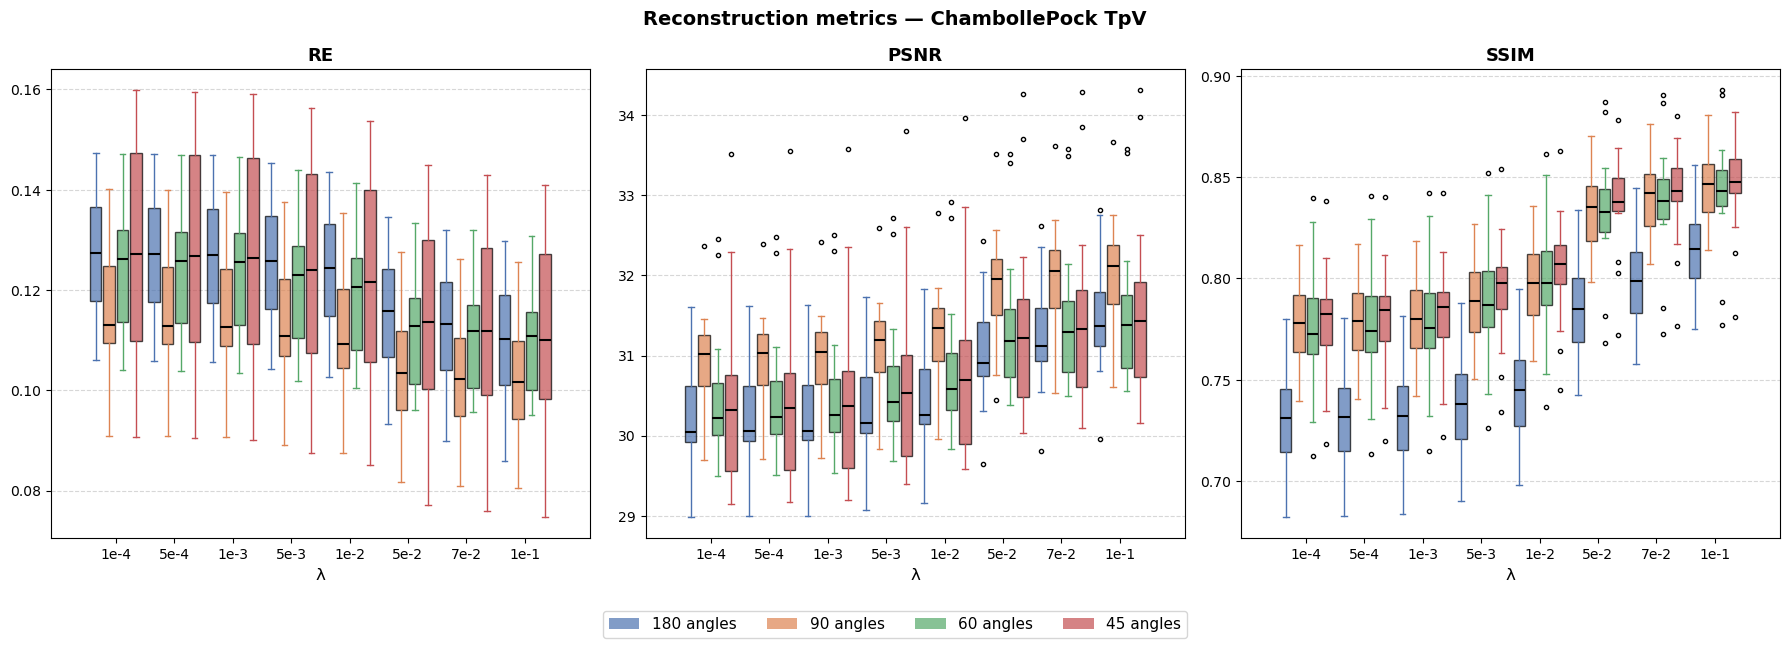

In [ ]:
'''
import matplotlib.pyplot as plt
import numpy as np

metrics_names = ["RE", "PSNR", "SSIM"]
lambdas = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 7e-2, 1e-1]
lambda_labels = ["1e-4", "5e-4", "1e-3", "5e-3", "1e-2", "5e-2", "7e-2", "1e-1"]
n_angles_list = [180, 90, 60, 45]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

n_lambdas = len(lambdas)
n_angles  = len(n_angles_list)
width     = 0.15  # larghezza di ogni box
spacing   = 0.05  # spazio tra gruppi

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric in zip(axes, metrics_names):
    for j, (n_ang, color) in enumerate(zip(n_angles_list, colors)):
        positions = []
        data      = []
        for i, lmbda in enumerate(lambdas):
            pos = i * (n_angles * width + spacing) + j * width
            positions.append(pos)
            data.append(results[n_ang][lmbda][metric])

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.7),
            medianprops=dict(color="black", linewidth=1.5),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
            flierprops=dict(marker="o", color=color, markersize=3),
        )

    # Tick al centro di ogni gruppo di 4 box
    group_width = n_angles * width + spacing
    tick_positions = [i * group_width + (n_angles - 1) * width / 2 for i in range(n_lambdas)]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(lambda_labels, fontsize=10)
    ax.set_xlabel("λ", fontsize=12)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Legenda unica
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=c, alpha=0.7)
    for c in colors
]
fig.legend(handles, [f"{a} angles" for a in n_angles_list],
           loc="lower center", ncol=4, fontsize=11, bbox_to_anchor=(0.5, -0.08))

plt.suptitle("Reconstruction metrics — ChambollePock TpV", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("boxplot_results.png", dpi=150, bbox_inches="tight")
plt.show()
'''

In [3]:
import os
import numpy as np
from tqdm import tqdm

RECO_BASE_PATH = "../data/reco"
BEST_LAMBDA = 1e-2

for n_angles in ANGLE_CONFIGS:
    print(f"\n===== {n_angles} ANGLES =====")
    K = operators_dict[n_angles]
    solver = solvers.ChambollePockTpVUnconstrained(K)

    for split in ["train", "validation", "test"]:
        print(f"  -- split: {split} --")

        # Crea cartella di destinazione
        save_dir = os.path.join(RECO_BASE_PATH, f"angles_{n_angles}", split)
        os.makedirs(save_dir, exist_ok=True)

        loader = dataloaders[split][n_angles]

        for idx, (y_delta, y_clean, x_true) in enumerate(tqdm(loader, desc=f"{n_angles}a/{split}")):
            y_delta = y_delta.to(device)
            x_true  = x_true.to(device)

            x_sol, _ = solver(
                y_delta,
                lmbda=BEST_LAMBDA,
                starting_point=None,
                x_true=x_true,
                maxiter=maxiter,
                p=p,
                verbose=False,
            )

            # x_sol: [1, 1, H, W] -> [H, W] -> salva come .npy
            x_sol_np = x_sol.cpu().squeeze().detach().numpy()  # shape (256, 256)
            np.save(os.path.join(save_dir, f"reco_{idx:04d}.npy"), x_sol_np)

print("\nDone! Ricostruzioni salvate in ../data/reco/")

NameError: name 'ANGLE_CONFIGS' is not defined